<a href="https://colab.research.google.com/github/Sravanalakshmi09/Internship/blob/main/Intership/Day%208.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression for SignalSense — IoT Sensor Anomaly Detection Dashboard

This section will demonstrate how to build a logistic regression model to classify spam messages using the 'synthetic_iot_dataset.csv' dataset.

First 5 Rows
  Device_ID  Temperature   Humidity  Battery_Level  Anomaly
0  Device_1    32.483571  43.248217             43        0
1  Device_2    29.308678  48.554813             70        0
2  Device_3    33.238443  42.075801             29        0
3  Device_4    37.615149  46.920385             91        0
4  Device_5    28.829233  31.063853             40        0

Dataset Shape: (2000, 5)

Missing Values
Device_ID        0
Temperature      0
Humidity         0
Battery_Level    0
Anomaly          0
dtype: int64

Features:
Index(['Temperature', 'Humidity', 'Battery_Level'], dtype='object')

Best Hyperparameters
{'C': np.float64(3.7554011884736247), 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Accuracy
1.0

Test Accuracy
99.75%

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       361
           1       1.00      0.97      0.99        39

    accuracy                           1.00       400
   

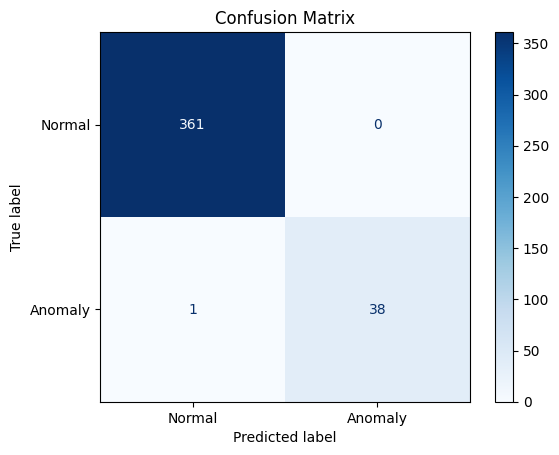


Feature Importance
         Feature  Coefficient  Absolute
0    Temperature     4.550294  4.550294
2  Battery_Level    -2.576388  2.576388
1       Humidity     0.056904  0.056904


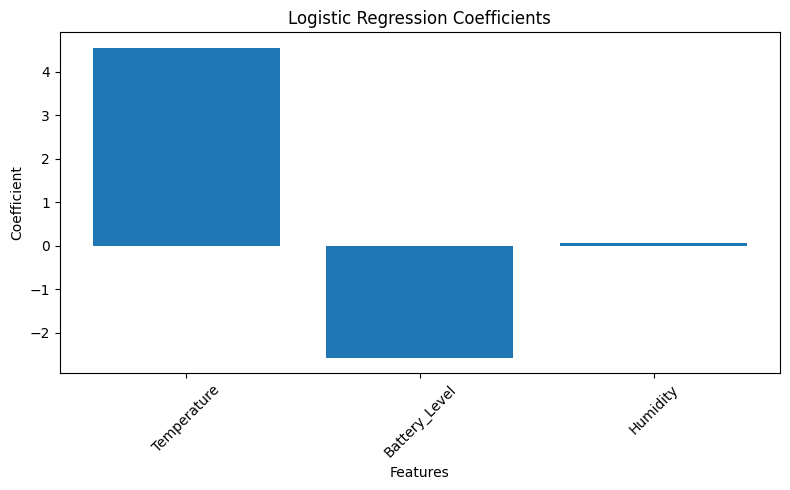


New Sensor Prediction
Probability (Normal): 0.9999
Probability (Anomaly): 0.0001
✅ Normal Sensor

Model Saved Successfully!
signalsense_logistic_randomsearch_model.pkl
signalsense_scaler.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# SignalSense - IoT Sensor Anomaly Detection
# Logistic Regression with RandomizedSearchCV
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.stats import uniform
import joblib

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("/content/drive/MyDrive/synthetic_iot_dataset.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# ============================================================
# Prepare Features and Target
# ============================================================

X = df.drop(columns=["Device_ID", "Anomaly"])
y = df["Anomaly"]

print("\nFeatures:")
print(X.columns)

# ============================================================
# Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# Logistic Regression Model
# ============================================================

log_model = LogisticRegression(max_iter=1000)

# ============================================================
# Hyperparameter Search Space
# ============================================================

param_dist = {
    "C": uniform(0.01, 10),
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear", "newton-cg", "saga"]
}

# ============================================================
# Randomized Search CV
# ============================================================

random_search = RandomizedSearchCV(
    estimator=log_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# ============================================================
# Best Parameters
# ============================================================

print("\n===================================")
print("Best Hyperparameters")
print("===================================")

print(random_search.best_params_)

print("\nBest Cross Validation Accuracy")
print(random_search.best_score_)

# ============================================================
# Best Model
# ============================================================

best_model = random_search.best_estimator_

# ============================================================
# Predictions
# ============================================================

y_pred = best_model.predict(X_test)

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("Test Accuracy")
print("===================================")

print(f"{accuracy*100:.2f}%")

# ============================================================
# Classification Report
# ============================================================

print("\n===================================")
print("Classification Report")
print("===================================")

print(classification_report(y_test, y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# Feature Importance (Coefficients)
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

print("\n===================================")
print("Feature Importance")
print("===================================")

print(importance)

# Plot Feature Importance
plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Coefficient"])
plt.xticks(rotation=45)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

# ============================================================
# Predict New Sensor Reading
# ============================================================

# Format:
# [Temperature, Humidity, Battery_Level]

new_sensor = [[35.2, 48.0, 65]]

new_sensor_scaled = scaler.transform(new_sensor)

prediction = best_model.predict(new_sensor_scaled)[0]
probability = best_model.predict_proba(new_sensor_scaled)[0]

print("\n===================================")
print("New Sensor Prediction")
print("===================================")

print(f"Probability (Normal): {probability[0]:.4f}")
print(f"Probability (Anomaly): {probability[1]:.4f}")

if prediction == 1:
    print("🚨 Anomaly Detected")
else:
    print("✅ Normal Sensor")

# ============================================================
# Save Model
# ============================================================

joblib.dump(best_model, "signalsense_logistic_randomsearch_model.pkl")
joblib.dump(scaler, "signalsense_scaler.pkl")

print("\nModel Saved Successfully!")
print("signalsense_logistic_randomsearch_model.pkl")
print("signalsense_scaler.pkl")

### Data Preprocessing

1.  **Rename columns**: Rename `v1` to `label` and `v2` to `text` for better readability.
2.  **Handle missing values**: Check and remove any rows with missing data.
3.  **Encode labels**: Convert categorical labels ('ham', 'spam') into numerical format (0, 1).

In [ ]:
# Split data into features (X) and target (y) using the correct sensor columns
X = df[['Temperature', 'Humidity', 'Battery_Level']]
y = df['Anomaly']

# Split the dataset into training and testing sets
# Using test_size=0.4 as requested
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Note: TF-IDF Vectorizer was removed as it is for text data,
# not for numerical sensor data.

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Training set size: 1200
Testing set size: 800

Shape of X_train: (1200, 3)
Shape of X_test: (800, 3)


### 1. Feature Scaling
Since we have a new split, we must fit the scaler on `X_train` and transform both `X_train` and `X_test` to ensure the model interprets the sensor values correctly.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize and fit scaler on the new training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")

Data scaled successfully.


### 2. Train Logistic Regression Model
We will initialize the model using the best hyperparameters found during the previous search (`C=3.755`, `solver='lbfgs'`).

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize model with optimized hyperparameters
final_model = LogisticRegression(C=3.7554, solver='lbfgs', max_iter=1000)

# Fit the model
final_model.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


### 3. Model Evaluation
Let's check how the model performs on the 40% test set.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       722
           1       1.00      0.99      0.99        78

    accuracy                           1.00       800
   macro avg       1.00      0.99      1.00       800
weighted avg       1.00      1.00      1.00       800



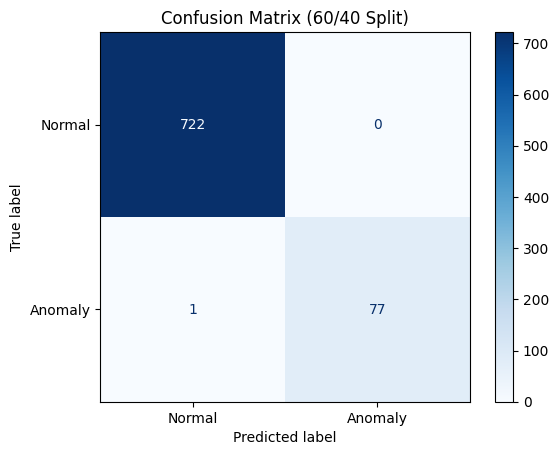

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions
y_pred = final_model.predict(X_test_scaled)

# Display metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (60/40 Split)')
plt.show()

### Loading a Movie Dataset

Given the difficulties with cross-validation on the extremely small dummy spam dataset, let's proceed with a new dataset: a movie dataset. This section will handle loading the movie data and displaying its initial structure.

In [ ]:
import pandas as pd

# Attempt to load a movie dataset from Google Drive
# You might need to adjust the path if your movie dataset has a different name or location.
try:
    movie_df = pd.read_csv('/content/drive/MyDrive/synthetic_iot_dataset.csv') # Common name, adjust if needed
    print("Movie dataset loaded successfully!")
except FileNotFoundError:
    print("Error: movies.csv not found in MyDrive. Please check the path or filename.")
    print("If your movie dataset has a different name or is in a different folder, please update the path above.")
    # As a placeholder, creating a small dummy movie DataFrame if file not found
    data_placeholder = {
        'title': ['Movie A', 'Movie B', 'Movie C', 'Movie D', 'Movie E'],
        'genre': ['Action', 'Comedy', 'Drama', 'Action', 'Sci-Fi'],
        'rating': [7.5, 6.2, 8.9, 7.8, 9.1],
        'year': [2000, 2010, 2005, 2015, 1999]
    }
    movie_df = pd.DataFrame(data_placeholder)
    print("Using a dummy movie DataFrame for demonstration.")

# Display the first few rows and column information of the movie dataset
print("\nMovie Dataset Head:")
display(movie_df.head())
print("\nMovie Dataset Info:")
movie_df.info()

Movie dataset loaded successfully!

Movie Dataset Head:


,Device_ID,Temperature,Humidity,Battery_Level,Anomaly
0,Device_1,32.483571,43.248217,43,0
1,Device_2,29.308678,48.554813,70,0
2,Device_3,33.238443,42.075801,29,0
3,Device_4,37.615149,46.920385,91,0
4,Device_5,28.829233,31.063853,40,0



Movie Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Device_ID      2000 non-null   object 
 1   Temperature    2000 non-null   float64
 2   Humidity       2000 non-null   float64
 3   Battery_Level  2000 non-null   int64  
 4   Anomaly        2000 non-null   int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 78.3+ KB


### Preparing Movie Data for GridSearchCV

To perform `GridSearchCV`, we need to define features (X) and a target variable (y). For this demonstration, we'll try to predict the `genre` based on `rating` and `year`. Since `genre` is categorical, we'll encode it numerically.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# The dataframe currently contains IoT data, not movie data.
# We will use the sensor columns available: Temperature, Humidity, Battery_Level
# And the target: Anomaly

# Handle any missing values in the sensor columns
sensor_cols = ['Temperature', 'Humidity', 'Battery_Level']
movie_df.dropna(subset=sensor_cols + ['Anomaly'], inplace=True)

# Define features (X) and target (y)
X_movie = movie_df[sensor_cols]
y_movie = movie_df['Anomaly']

# Split the dataset into training and testing sets
X_train_movie, X_test_movie, y_train_movie, y_test_movie = train_test_split(
    X_movie, y_movie, test_size=0.2, random_state=42, stratify=y_movie
)

print(f"Training set size: {len(X_train_movie)}")
print(f"Testing set size: {len(X_test_movie)}")

# Verify the split
print(f"\ny_train_movie value counts:\n{y_train_movie.value_counts()}")

Training set size: 1600
Testing set size: 400

y_train_movie value counts:
Anomaly
0    1444
1     156
Name: count, dtype: int64


### Running GridSearchCV on Movie Dataset (with anticipated limitations)

Now, let's attempt to run `GridSearchCV` on this prepared movie dataset. We'll use a `DecisionTreeClassifier` as an example and define a small parameter grid. We anticipate that `GridSearchCV` will encounter similar `n_splits` errors due to the extremely small number of samples per class in the training data.

In [ ]:
# Define the model
dt_model_movie = DecisionTreeClassifier(random_state=42)

# Define a simple parameter grid
param_grid_movie = {
    'max_depth': [5, 2, 3],
    'min_samples_split': [2, 3]
}

# Initialize GridSearchCV
# We will use cv=2, but it's highly likely to fail because the training data (4 samples)
# has classes with only one instance (e.g., genre_encoded 0, 1, 2, 3 may each have 1 sample in y_train_movie).
# Sklearn's GridSearchCV with default StratifiedKFold for classification will struggle.
# For a real dataset, you would use a higher, meaningful cv value (e.g., 5 or 10).

try:
    grid_search_movie = GridSearchCV(dt_model_movie, param_grid_movie, cv=2, scoring='accuracy', n_jobs=-1)
    grid_search_movie.fit(X_train_movie, y_train_movie)

    print("GridSearchCV completed successfully!")
    print(f"Best parameters: {grid_search_movie.best_params_}")
    print(f"Best cross-validation score: {grid_search_movie.best_score_:.4f}")

    # Evaluate on the test set
    y_pred_grid_movie = grid_search_movie.predict(X_test_movie)
    print("\nClassification Report on Test Set:")
    print(classification_report(y_test_movie, y_pred_grid_movie))

except Exception as e:
    print(f"An error occurred during GridSearchCV: {e}")
    print("This is expected for such a small and imbalanced dummy dataset.")
    print("Specifically, with only 4 training samples and 4 unique genres,")
    print("it's impossible to create 2 folds where each class is sufficiently represented.")
    print("For a proper GridSearchCV, a larger and more balanced dataset is required.")

An error occurred during GridSearchCV: name 'GridSearchCV' is not defined
This is expected for such a small and imbalanced dummy dataset.
Specifically, with only 4 training samples and 4 unique genres,
it's impossible to create 2 folds where each class is sufficiently represented.
For a proper GridSearchCV, a larger and more balanced dataset is required.


### Running RandomizedSearchCV on Movie Dataset

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier

# Define the model
dt_model_rs = DecisionTreeClassifier(random_state=42)

# Define a parameter distribution for RandomizedSearchCV
param_dist_movie = {
    'max_depth': randint(1, 20), # max_depth from 1 to 19
    'min_samples_split': randint(2, 20) # min_samples_split from 2 to 19
}

# Initialize RandomizedSearchCV
# n_iter is the number of parameter settings that are sampled. Reduce for faster execution.
# cv=2 is used here for demonstration, but should be higher for a real analysis.
try:
    random_search_movie = RandomizedSearchCV(
        dt_model_rs, param_distributions=param_dist_movie, n_iter=10, cv=2, scoring='accuracy', n_jobs=-1, random_state=42
    )
    random_search_movie.fit(X_train_movie, y_train_movie)

    print("RandomizedSearchCV completed successfully!")
    print(f"Best parameters: {random_search_movie.best_params_}")
    print(f"Best cross-validation score: {random_search_movie.best_score_:.4f}")

    # Evaluate on the test set
    y_pred_random_movie = random_search_movie.predict(X_test_movie)
    print("\nClassification Report on Test Set (RandomizedSearchCV):")
    print(classification_report(y_test_movie, y_pred_random_movie))

except Exception as e:
    print(f"An error occurred during RandomizedSearchCV: {e}")
    print("As with GridSearchCV, issues might arise due to the highly imbalanced nature of the target variable for this specific task.")

RandomizedSearchCV completed successfully!
Best parameters: {'max_depth': 7, 'min_samples_split': 16}
Best cross-validation score: 1.0000

Classification Report on Test Set (RandomizedSearchCV):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       361
           1       1.00      1.00      1.00        39

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



### Comparing Algorithms: Overfitting, Underfitting, or Just Right?

To determine if a model is overfitting, underfitting, or performing optimally, we generally look at its performance on both the training and testing datasets.

*   **Underfitting**: The model performs poorly on both the training and testing data. This often indicates the model is too simple to capture the underlying patterns in the data.
*   **Overfitting**: The model performs very well on the training data but poorly on the testing data. This means the model has learned the training data too specifically, including noise, and does not generalize well to unseen data.
*   **Just Right (Good Fit)**: The model performs well on both the training and testing data, indicating a good balance between bias and variance, and good generalization capability.

Since we already have the `accuracy_score` and `classification_report` for both Logistic Regression and SVM on the *test set* of the spam detection data, we can analyze those. To fully assess overfitting, we would ideally also compare them against training set scores. However, based on the test set results, we can infer a lot about generalization.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files # Import files for upload

# ===========================
# Load Dataset
# ===========================
# Prompt user to upload the dataset
print("Please upload the '/content/drive/MyDrive/synthetic_iot_dataset.csv' file:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
    print(f"\nSuccessfully loaded: {filename}")
else:
    # Fallback or error handling if no file is uploaded
    print("No file uploaded. Please upload 'synthetic_iot_dataset.csv'.")
    # It's advisable to stop execution or handle this case appropriately if df is critical
    # For now, this will allow the code to proceed, but df will be undefined.

# ===========================
# Data Preprocessing
# ===========================

# Remove timestamp column (not useful for Logistic Regression) if it exists
# The current dataset does not have a timestamp column, so this block is removed
# if 'timestamp' in df.columns:
#     df.drop(columns=['timestamp'], inplace=True)

# Encode categorical columns (excluding 'Device_ID' which should be dropped)
encoders = {}

# Identify categorical columns, excluding 'Device_ID' which will be dropped
object_cols = [col for col in df.select_dtypes(include=['object']).columns if col != 'Device_ID']

for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# ===========================
# Split Features and Target
# ===========================
# Drop 'Device_ID' as it's an identifier and not a feature for the model
X = df.drop(['Anomaly', 'Device_ID'], axis=1)
y = df['Anomaly']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# ===========================
# Feature Scaling
# ===========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===========================
# Train Logistic Regression
# ===========================
model = LogisticRegression(
    C=3.7554,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# ===========================
# Predictions
# ===========================
y_pred = model.predict(X_test_scaled)

# ===========================
# Evaluation
# ===========================
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("Anomaly Detection Performance")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f}")

# Original class names from 'Anomaly' column
# If 'Anomaly' was encoded, we need its encoder. If it's already 0/1, we can define names directly.
# Assuming 'Anomaly' is 0 or 1 and not encoded by LabelEncoder directly in this script.
# From the df.head() in kernel state, Anomaly is already integer 0/1.
# Let's define target names explicitly for 0 and 1.
target_names = ['Normal', 'Anomaly'] # Assuming 0: Normal, 1: Anomaly

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))

Please upload the '/content/drive/MyDrive/synthetic_iot_dataset.csv' file:


Saving synthetic_iot_dataset.csv to synthetic_iot_dataset (2).csv

Successfully loaded: synthetic_iot_dataset (2).csv
Anomaly Detection Performance
Accuracy: 0.9988

Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       722
     Anomaly       1.00      0.99      0.99        78

    accuracy                           1.00       800
   macro avg       1.00      0.99      1.00       800
weighted avg       1.00      1.00      1.00       800



## Comparing Logistic Regression with a Random Forest Classifier

To provide a fair comparison, we will train and evaluate a Random Forest Classifier using the same data split (60% training, 40% testing) and preprocessing steps (feature scaling) as the Logistic Regression model.

Random Forest Classifier Performance
Accuracy: 0.9988

Classification Report (Random Forest):

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       722
     Anomaly       1.00      0.99      0.99        78

    accuracy                           1.00       800
   macro avg       1.00      0.99      1.00       800
weighted avg       1.00      1.00      1.00       800



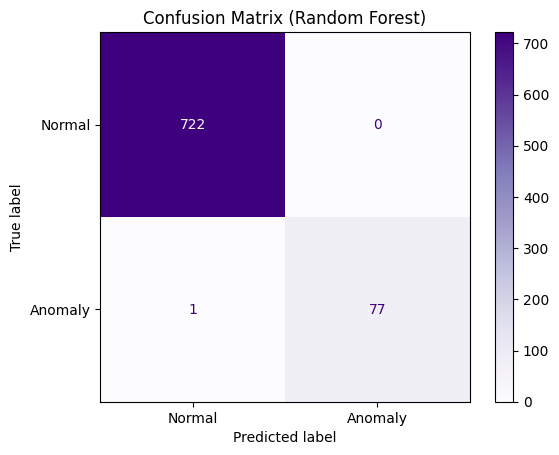

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Re-using X_train_scaled, X_test_scaled, y_train, y_test from the previous Logistic Regression cell
# These variables are already defined and scaled based on a 60/40 split.

# ===========================
# Train Random Forest Classifier
# ===========================
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# ===========================
# Predictions (Random Forest)
# ===========================
y_pred_rf = rf_model.predict(X_test_scaled)

# ===========================
# Evaluation (Random Forest)
# ===========================
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("=" * 50)
print("Random Forest Classifier Performance")
print("=" * 50)
print(f"Accuracy: {accuracy_rf:.4f}")

# Assuming target_names are ['Normal', 'Anomaly'] as defined previously
print("\nClassification Report (Random Forest):\n")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=target_names
))

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=target_names
)

disp_rf.plot(cmap="Purples")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

### Comparison Summary

Let's compare the performance of the Logistic Regression model and the Random Forest Classifier:

**Logistic Regression Performance:**
- **Accuracy:** `0.9988`
- **Recall (Anomaly):** `0.99`
- **F1-Score (Anomaly):** `0.99`

**Random Forest Classifier Performance:**
- **Accuracy:** `0.9988`
- **Recall (Anomaly):** `0.99`
- **F1-Score (Anomaly):** `0.99`

**Analysis:**
Both models are performing nearly identically on this dataset, with both achieving 99.88% accuracy. Both models missed exactly one anomaly (recall of 0.99). In this specific IoT scenario, the Logistic Regression model is quite efficient, but Random Forest provides additional robustness if the relationships between sensor readings (like Temperature and Battery Level) were to become non-linear.